# Time Series on Air Temperture

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading the data
df = pd.read_csv("E:/Datasets/AirTempTS/Data/surface-air-temperature-monthly-mean.csv")


In [4]:
# Basic check on data
df.head()

,month,mean_temp
0,1982-01,25.9
1,1982-02,27.1
2,1982-03,27.2
3,1982-04,27.0
4,1982-05,28.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   month      462 non-null    object 
 1   mean_temp  462 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.3+ KB


In [5]:
df.isnull().sum()

month        0
mean_temp    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,mean_temp
count,462.000000
mean,27.665152
std,0.808186
min,25.400000
25%,27.100000
50%,27.700000
75%,28.300000
max,29.500000


### EDA

In [17]:
df['month'] = pd.to_datetime(df['month'])
df.set_index('month', inplace=True)

In [25]:
df.index

DatetimeIndex(['1982-01-01', '1982-02-01', '1982-03-01', '1982-04-01',
               '1982-05-01', '1982-06-01', '1982-07-01', '1982-08-01',
               '1982-09-01', '1982-10-01',
               ...
               '2019-09-01', '2019-10-01', '2019-11-01', '2019-12-01',
               '2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01',
               '2020-05-01', '2020-06-01'],
              dtype='datetime64[ns]', name='month', length=462, freq=None)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 462 entries, 1982-01-01 to 2020-06-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mean_temp  462 non-null    float64
dtypes: float64(1)
memory usage: 7.2 KB


<Axes: ylabel='mean_temp'>

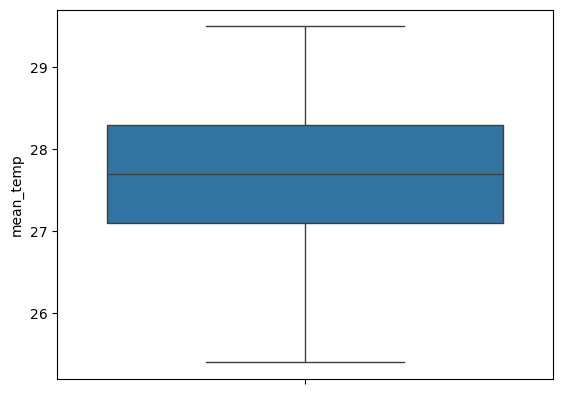

In [18]:
sns.boxplot(data=df['mean_temp'])

<Axes: xlabel='month', ylabel='mean_temp'>

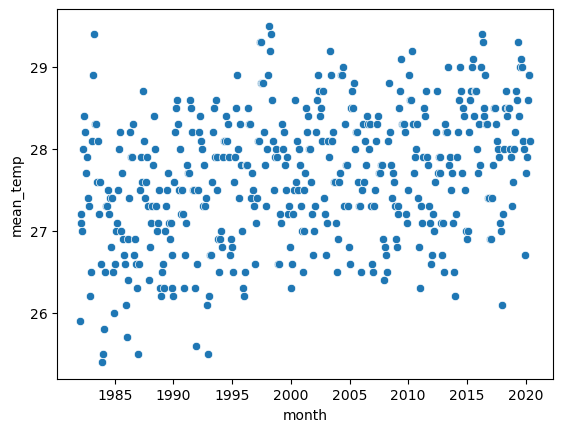

In [21]:
sns.scatterplot(data=df['mean_temp'])

<Axes: xlabel='mean_temp', ylabel='Count'>

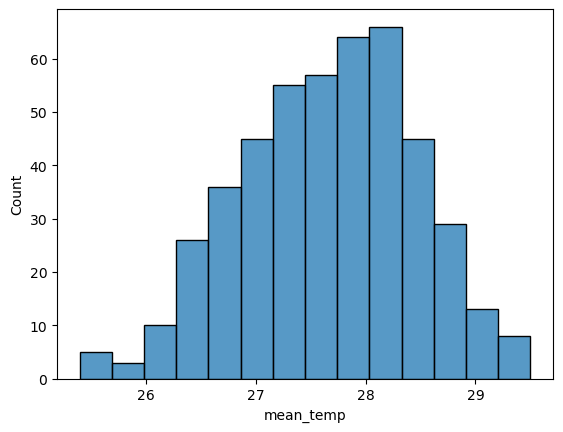

In [23]:
sns.histplot(data=df['mean_temp'])

## Model Creation

In [35]:
# Creating target column
df['target'] = df['mean_temp'].shift(-1)
df.tail()
# droping last column
df = df.dropna()
df.tail()

,mean_temp,target
month,,
2020-01-01,27.7,27.9
2020-02-01,27.9,28.6
2020-03-01,28.6,28.9
2020-04-01,28.9,28.9
2020-05-01,28.9,28.1


In [36]:
# Creating x and y